# Student Performance Analysis

This notebook analyzes student performance using the UCI Student Performance dataset and develops two **early prediction models**.

**Objective:** estimate a student's final grade and identify whether the student may be academically at risk using information available before the final grade is known.

> **Risk definition:** `G3 < 10` → at risk.

The project uses:
- **Regression** to predict the final grade (`G3`)
- **Classification** to predict academic risk (`G3 < 10`)

## 1. Imports and Dataset Loading

In [150]:
import joblib
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind, f_oneway

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor
)
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, fbeta_score, roc_auc_score, confusion_matrix,
    classification_report, precision_recall_curve,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, KFold,
    cross_validate, cross_val_predict, RandomizedSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

df = pd.read_csv("../data/raw/student-mat.csv", sep=";")
df.head()


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## 2. Dataset Overview

In [151]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

print("\nMissing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

df.info()


Rows: 395
Columns: 33

Missing values: 0
Duplicate rows: 0
<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-nul

In [152]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
age,395.0,16.696203,1.276043,15.0,16.0,17.0,18.0,22.0
Medu,395.0,2.749367,1.094735,0.0,2.0,3.0,4.0,4.0
Fedu,395.0,2.521519,1.088201,0.0,2.0,2.0,3.0,4.0
traveltime,395.0,1.448101,0.697505,1.0,1.0,1.0,2.0,4.0
studytime,395.0,2.035443,0.839240,1.0,1.0,2.0,2.0,4.0
failures,395.0,0.334177,0.743651,0.0,0.0,0.0,0.0,3.0
famrel,395.0,3.944304,0.896659,1.0,4.0,4.0,5.0,5.0
freetime,395.0,3.235443,0.998862,1.0,3.0,3.0,4.0,5.0
goout,395.0,3.108861,1.113278,1.0,2.0,3.0,4.0,5.0
Dalc,395.0,1.481013,0.890741,1.0,1.0,1.0,2.0,5.0


### Data-quality checks

The main numeric variables are checked for plausible ranges before modeling.

In [153]:
range_checks = {
    "age": (df["age"].min(), df["age"].max()),
    "studytime": (df["studytime"].min(), df["studytime"].max()),
    "failures": (df["failures"].min(), df["failures"].max()),
    "absences": (df["absences"].min(), df["absences"].max()),
    "G1": (df["G1"].min(), df["G1"].max()),
    "G2": (df["G2"].min(), df["G2"].max()),
    "G3": (df["G3"].min(), df["G3"].max())
}

for feature, (minimum, maximum) in range_checks.items():
    print(f"{feature:10} min={minimum:>5} max={maximum:>5}")


age        min=   15 max=   22
studytime  min=    1 max=    4
failures   min=    0 max=    3
absences   min=    0 max=   75
G1         min=    3 max=   19
G2         min=    0 max=   19
G3         min=    0 max=   20


## 3. Target Analysis

`G3` is the final mathematics grade on a 0–20 scale.

In [154]:
print("G3 summary:")
print(df["G3"].describe())

print("\nGrade distribution:")
print(df["G3"].value_counts().sort_index())


G3 summary:
count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64

Grade distribution:
G3
0     38
4      1
5      7
6     15
7      9
8     32
9     28
10    56
11    47
12    31
13    31
14    27
15    33
16    16
17     6
18    12
19     5
20     1
Name: count, dtype: int64


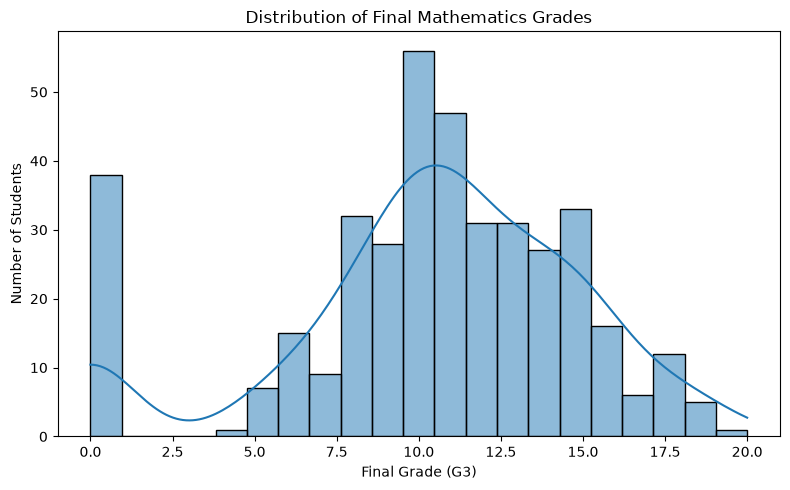

In [155]:
plt.figure(figsize=(8, 5))
sns.histplot(df["G3"], bins=21, kde=True)
plt.title("Distribution of Final Mathematics Grades")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()


## 4. Exploratory Data Analysis

The analysis focuses on factors that are useful for understanding performance and potential academic risk.

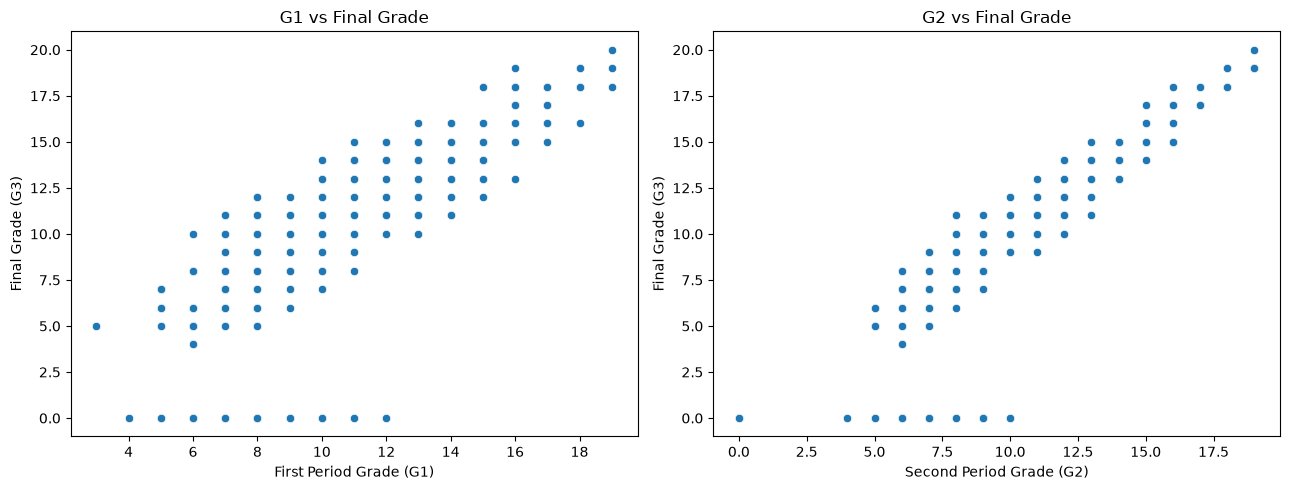

In [156]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(data=df, x="G1", y="G3", ax=axes[0])
axes[0].set_title("G1 vs Final Grade")
axes[0].set_xlabel("First Period Grade (G1)")
axes[0].set_ylabel("Final Grade (G3)")

sns.scatterplot(data=df, x="G2", y="G3", ax=axes[1])
axes[1].set_title("G2 vs Final Grade")
axes[1].set_xlabel("Second Period Grade (G2)")
axes[1].set_ylabel("Final Grade (G3)")

plt.tight_layout()
plt.show()


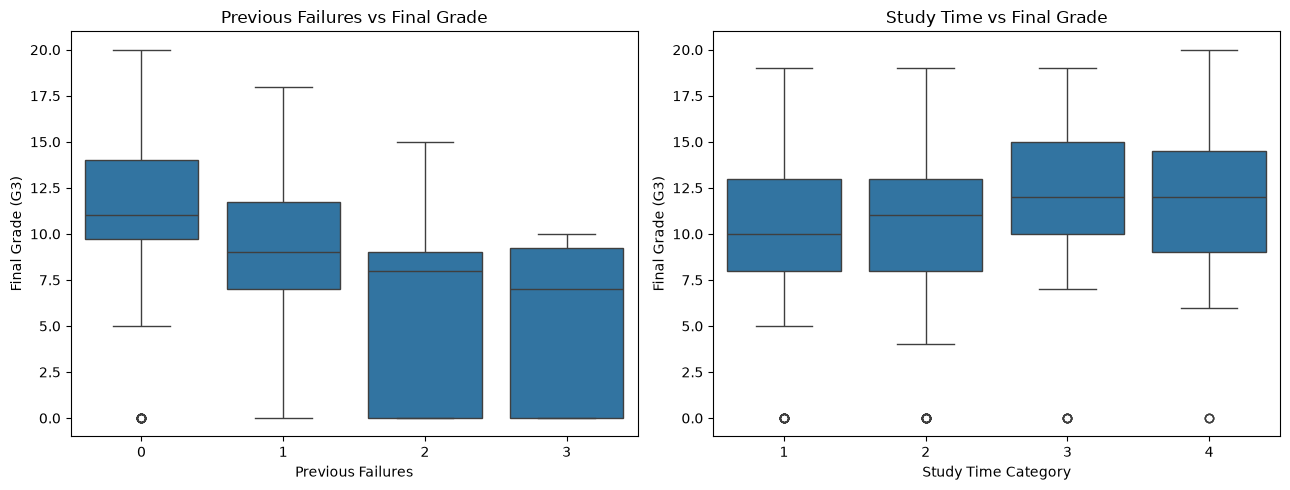

In [157]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x="failures", y="G3", ax=axes[0])
axes[0].set_title("Previous Failures vs Final Grade")
axes[0].set_xlabel("Previous Failures")
axes[0].set_ylabel("Final Grade (G3)")

sns.boxplot(data=df, x="studytime", y="G3", ax=axes[1])
axes[1].set_title("Study Time vs Final Grade")
axes[1].set_xlabel("Study Time Category")
axes[1].set_ylabel("Final Grade (G3)")

plt.tight_layout()
plt.show()


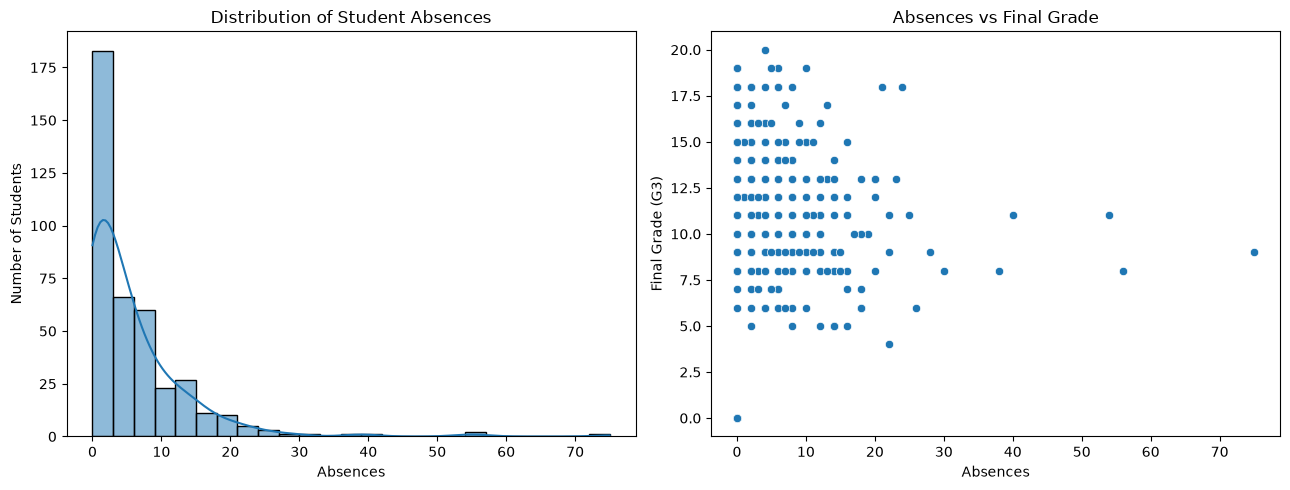

In [158]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(data=df, x="absences", bins=25, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Student Absences")
axes[0].set_xlabel("Absences")
axes[0].set_ylabel("Number of Students")

sns.scatterplot(data=df, x="absences", y="G3", ax=axes[1])
axes[1].set_title("Absences vs Final Grade")
axes[1].set_xlabel("Absences")
axes[1].set_ylabel("Final Grade (G3)")

plt.tight_layout()
plt.show()


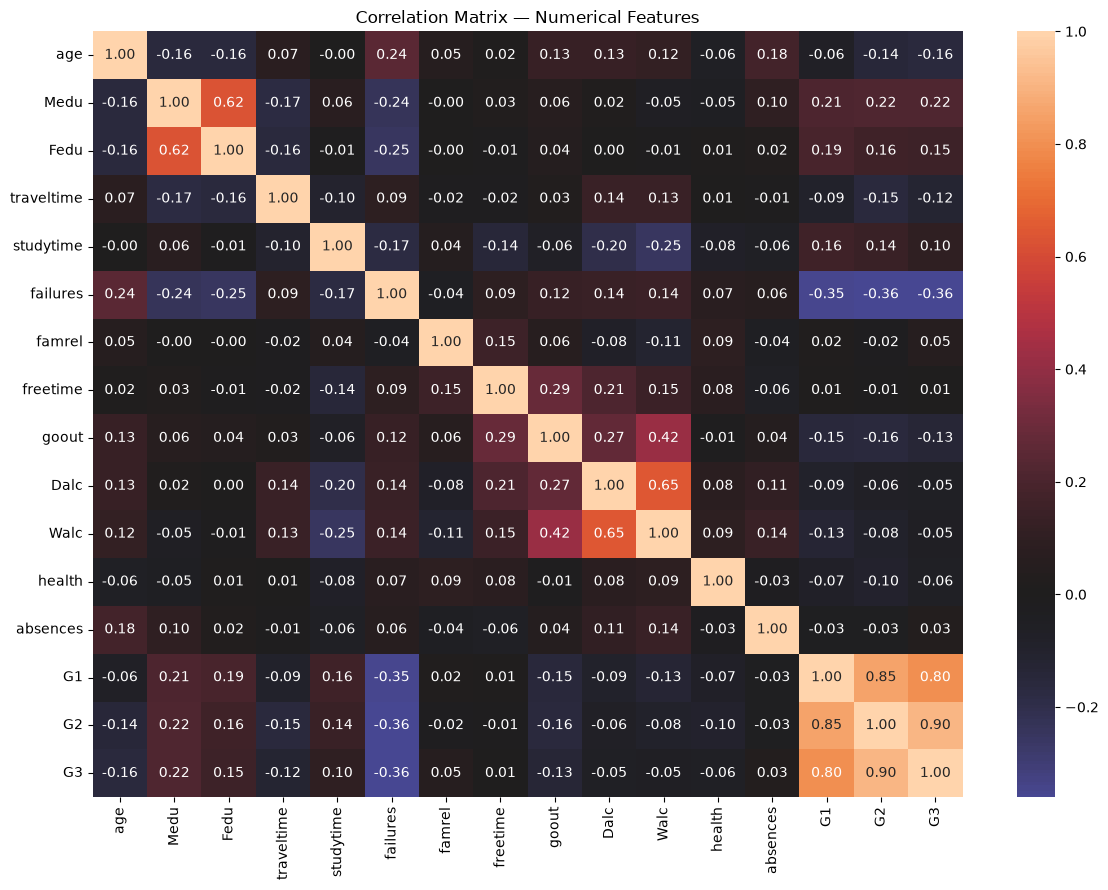

In [159]:
numeric_corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(12, 9))
sns.heatmap(numeric_corr, annot=True, fmt=".2f", center=0)
plt.title("Correlation Matrix — Numerical Features")
plt.tight_layout()
plt.show()


### Important modeling observation

`G1` and `G2` are strongly related to `G3`, but they represent grades obtained during the same academic period. For an **early-risk prediction** use case, they are excluded from the model so the prediction does not depend on later grades.

## 5. Categorical Performance Analysis

In [160]:
categorical_features_to_review = [
    "sex", "school", "address", "higher",
    "internet", "schoolsup", "famsup", "activities"
]

for feature in categorical_features_to_review:
    print(f"\n{feature}")
    print(
        df.groupby(feature)["G3"]
        .agg(["count", "mean", "median", "std"])
        .round(2)
    )



sex
     count   mean  median   std
sex                            
F      208   9.97    10.0  4.62
M      187  10.91    11.0  4.50

school
        count   mean  median   std
school                            
GP        349  10.49    11.0  4.63
MS         46   9.85    10.0  4.24

address
         count   mean  median   std
address                            
R           88   9.51    10.0  4.56
U          307  10.67    11.0  4.56

higher
        count   mean  median   std
higher                            
no         20   6.80     8.0  4.83
yes       375  10.61    11.0  4.49

internet
          count   mean  median   std
internet                            
no           66   9.41    10.0  4.49
yes         329  10.62    11.0  4.58

schoolsup
           count   mean  median   std
schoolsup                            
no           344  10.56    11.0  4.77
yes           51   9.43    10.0  2.87

famsup
        count   mean  median   std
famsup                            
no        153  10.6

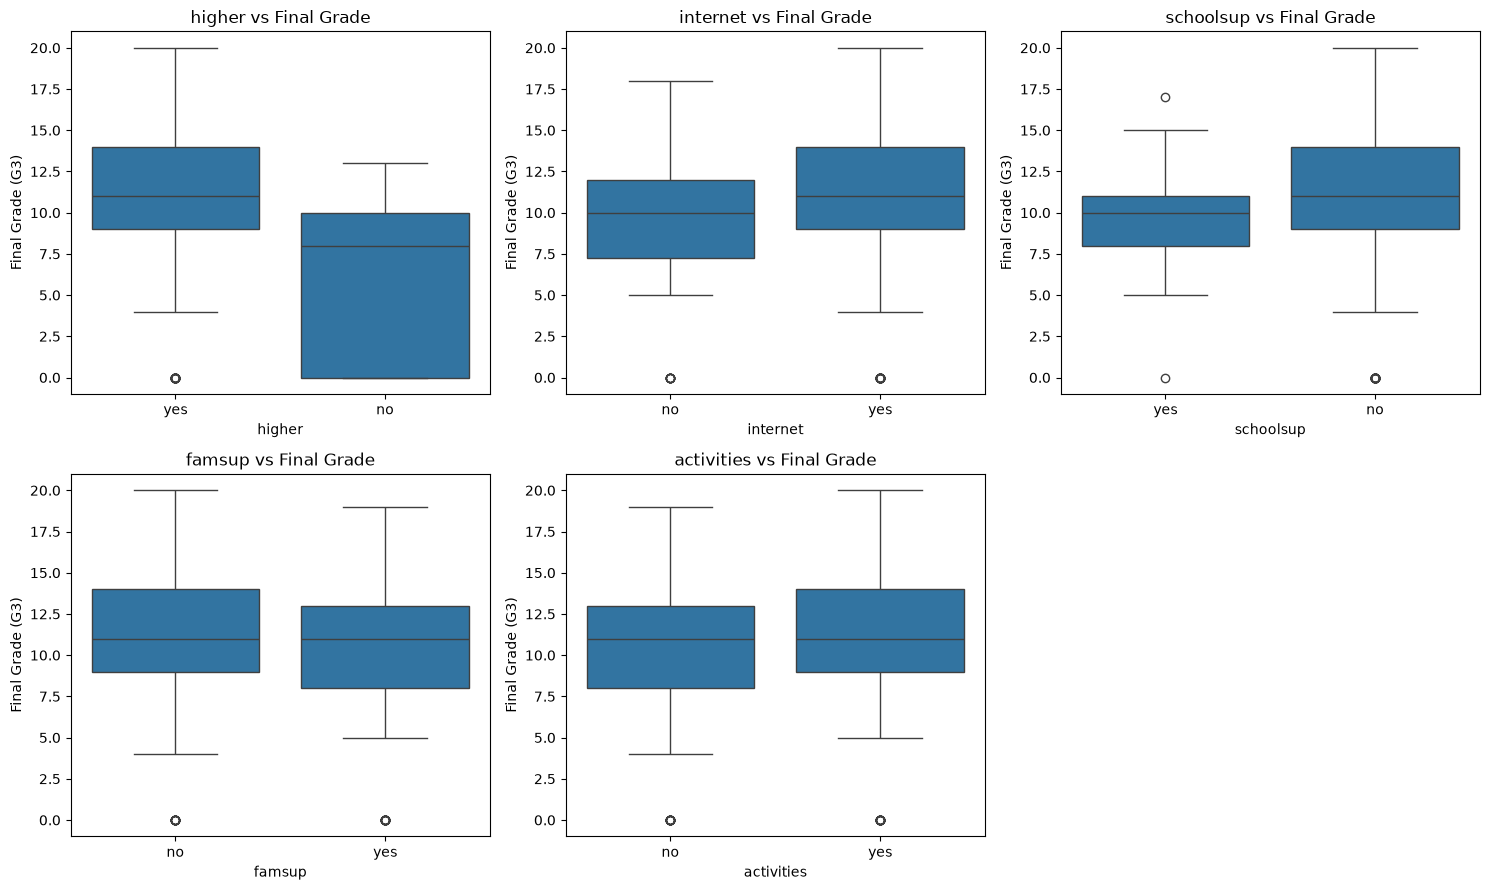

In [161]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
plot_features = ["higher", "internet", "schoolsup", "famsup", "activities"]

for ax, feature in zip(axes.flat, plot_features):
    sns.boxplot(data=df, x=feature, y="G3", ax=ax)
    ax.set_title(f"{feature} vs Final Grade")
    ax.set_xlabel(feature)
    ax.set_ylabel("Final Grade (G3)")

axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()


## 6. Statistical Analysis

These tests are used to supplement the visual analysis. They show whether observed group differences provide statistical evidence under the assumptions of the tests.

In [162]:
higher_yes = df.loc[df["higher"] == "yes", "G3"]
higher_no = df.loc[df["higher"] == "no", "G3"]

t_stat, p_value = ttest_ind(
    higher_yes,
    higher_no,
    equal_var=False
)

print("Welch's t-test: higher education intention")
print("t-statistic:", round(t_stat, 3))
print("p-value:", round(p_value, 4))


Welch's t-test: higher education intention
t-statistic: 3.447
p-value: 0.0024


In [163]:
failure_groups = [
    group["G3"].values
    for _, group in df.groupby("failures")
]

f_stat, p_value = f_oneway(*failure_groups)

print("One-way ANOVA: previous failures")
print("F-statistic:", round(f_stat, 3))
print("p-value:", round(p_value, 4))


One-way ANOVA: previous failures
F-statistic: 20.778
p-value: 0.0


## 7. Define Academic Risk

A student is classified as **at risk** when the final grade is below 10.

In [164]:
df["at_risk"] = (df["G3"] < 10).astype(int)

risk_counts = df["at_risk"].value_counts().sort_index()
risk_percent = df["at_risk"].value_counts(normalize=True).sort_index()

print("Risk counts:")
print(risk_counts)

print("\nRisk proportions:")
print(risk_percent.round(3))


Risk counts:
at_risk
0    265
1    130
Name: count, dtype: int64

Risk proportions:
at_risk
0    0.671
1    0.329
Name: proportion, dtype: float64


In [165]:
df.groupby("at_risk")["G3"].agg(
    count="count",
    mean="mean",
    median="median",
    min="min",
    max="max"
).round(2)


,count,mean,median,min,max
at_risk,,,,,
0,265,12.88,12.0,10,20
1,130,5.38,7.0,0,9


## 8. Model Setup

The project uses the same early-stage student features for two prediction tasks.

### Task 1 — Final Grade Regression
- Target: `G3`
- Excluded: `G1` and `G2` because the goal is early prediction
- Categorical variables: one-hot encoded
- Numerical variables: standardized

### Task 2 — Academic Risk Classification
- Target: `at_risk`, where `G3 < 10`
- Excluded: `G3` because it defines the target
- `G1` and `G2` are also excluded because they are later-period grades

For both tasks, preprocessing is placed inside the model pipeline to avoid data leakage during validation.

In [166]:
y = df["at_risk"]

drop_columns = ["G1", "G2", "G3", "at_risk"]
X = df.drop(columns=drop_columns)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 316
Testing samples: 79


In [167]:
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "string"]
).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))


Numerical features: 13
Categorical features: 17


## 9. Baseline Model — Logistic Regression

In [168]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=2000, random_state=42))
    ]
)

logistic_pipeline.fit(X_train, y_train)

logistic_pred = logistic_pipeline.predict(X_test)
logistic_prob = logistic_pipeline.predict_proba(X_test)[:, 1]


In [169]:
def evaluate_classifier(y_true, predictions, probabilities):
    return {
        "Accuracy": accuracy_score(y_true, predictions),
        "Precision": precision_score(y_true, predictions),
        "Recall": recall_score(y_true, predictions),
        "F1": f1_score(y_true, predictions),
        "ROC-AUC": roc_auc_score(y_true, probabilities)
    }

logistic_metrics = evaluate_classifier(
    y_test, logistic_pred, logistic_prob
)

pd.Series(logistic_metrics).round(3)


Accuracy     0.696
Precision    0.571
Recall       0.308
F1           0.400
ROC-AUC      0.715
dtype: float64

## 10. Random Forest

Random Forest is evaluated as a second model. `class_weight="balanced"` gives additional weight to the minority class, which is useful because identifying at-risk students is more important than optimizing accuracy alone.

In [170]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)
rf_prob = rf_pipeline.predict_proba(X_test)[:, 1]

rf_metrics = evaluate_classifier(
    y_test, rf_pred, rf_prob
)

pd.Series(rf_metrics).round(3)


Accuracy     0.709
Precision    0.571
Recall       0.462
F1           0.511
ROC-AUC      0.692
dtype: float64

In [171]:
model_comparison = pd.DataFrame(
    [logistic_metrics, rf_metrics],
    index=["Logistic Regression", "Random Forest"]
).round(3)

model_comparison


,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.696,0.571,0.308,0.400,0.715
Random Forest,0.709,0.571,0.462,0.511,0.692


## 11. Stratified 5-Fold Cross-Validation

Cross-validation checks whether the model comparison is consistent across multiple train/validation splits.

In [172]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

logistic_cv = cross_validate(
    logistic_pipeline, X, y,
    cv=cv, scoring=scoring, n_jobs=-1
)

rf_cv = cross_validate(
    rf_pipeline, X, y,
    cv=cv, scoring=scoring, n_jobs=-1
)


In [173]:
cv_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"],
    "Logistic Regression": [
        logistic_cv["test_accuracy"].mean(),
        logistic_cv["test_precision"].mean(),
        logistic_cv["test_recall"].mean(),
        logistic_cv["test_f1"].mean(),
        logistic_cv["test_roc_auc"].mean()
    ],
    "Random Forest": [
        rf_cv["test_accuracy"].mean(),
        rf_cv["test_precision"].mean(),
        rf_cv["test_recall"].mean(),
        rf_cv["test_f1"].mean(),
        rf_cv["test_roc_auc"].mean()
    ]
}).round(3)

cv_results


,Metric,Logistic Regression,Random Forest
0,Accuracy,0.678,0.699
1,Precision,0.514,0.552
2,Recall,0.369,0.462
3,F1,0.429,0.500
4,ROC-AUC,0.678,0.688


## 12. Hyperparameter Tuning

Because the objective is identifying at-risk students, **F1-score** is used to tune the Random Forest hyperparameters. This balances precision and recall.

After tuning the model, the classification decision threshold is optimized separately using **out-of-fold training probabilities**. F2-score is used for threshold selection because early intervention benefits from giving more weight to recall.

In [174]:
param_distributions = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [None, 4, 6, 8, 10],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None]
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    refit=True
)

rf_search.fit(X_train, y_train)

print("Best CV F1:", round(rf_search.best_score_, 3))
print("\nBest parameters:")
for parameter, value in rf_search.best_params_.items():
    print(f"{parameter}: {value}")


Best CV F1: 0.465

Best parameters:
model__n_estimators: 300
model__min_samples_split: 2
model__min_samples_leaf: 2
model__max_features: sqrt
model__max_depth: 8


## 13. Tune the Classification Threshold

The default classification threshold is 0.50, but it is not necessarily the best threshold for an early-intervention use case.

We first generate **out-of-fold probabilities from the training data** so the untouched test set is not used to choose the threshold. We then evaluate candidate thresholds between 0.20 and 0.80.

Because early intervention values recall, we use **F2-score** as the optimization metric, but we also require **specificity of at least 0.50**. This prevents the threshold from becoming so low that almost every student is flagged as at risk.

The final threshold is therefore:

> **the threshold with the highest F2-score among candidates that retain at least 50% specificity.**

The test set remains untouched during this selection step.

In [175]:
best_rf = rf_search.best_estimator_

oof_prob = cross_val_predict(
    best_rf,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

candidate_thresholds = [round(i / 100, 2) for i in range(20, 81)]

threshold_results = []

for threshold in candidate_thresholds:
    candidate_pred = (oof_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_train,
        candidate_pred,
        labels=[0, 1]
    ).ravel()

    specificity = tn / (tn + fp) if (tn + fp) else 0

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_train, candidate_pred, zero_division=0
        ),
        "Recall": recall_score(y_train, candidate_pred),
        "F1": f1_score(y_train, candidate_pred),
        "F2": fbeta_score(y_train, candidate_pred, beta=2),
        "Specificity": specificity
    })

threshold_results = pd.DataFrame(threshold_results)

valid_thresholds = threshold_results[
    threshold_results["Specificity"] >= 0.50
]

best_row = valid_thresholds.sort_values(
    ["F2", "F1"],
    ascending=False
).iloc[0]

best_threshold = float(best_row["Threshold"])

print("Best threshold:", best_threshold)
print("Out-of-fold F2:", round(best_row["F2"], 3))
print("Out-of-fold precision:", round(best_row["Precision"], 3))
print("Out-of-fold recall:", round(best_row["Recall"], 3))
print("Out-of-fold specificity:", round(best_row["Specificity"], 3))

print("\nCandidate thresholds:")
display(
    valid_thresholds[
        ["Threshold", "Precision", "Recall", "F1", "F2", "Specificity"]
    ].round(3)
)

Best threshold: 0.42
Out-of-fold F2: 0.587
Out-of-fold precision: 0.401
Out-of-fold recall: 0.663
Out-of-fold specificity: 0.514

Candidate thresholds:


,Threshold,Precision,Recall,F1,F2,Specificity
22,0.42,0.401,0.663,0.500,0.587,0.514
23,0.43,0.405,0.635,0.494,0.570,0.542
24,0.44,0.397,0.577,0.471,0.529,0.571
25,0.45,0.413,0.567,0.478,0.528,0.604
26,0.46,0.444,0.567,0.498,0.537,0.651
27,0.47,0.446,0.519,0.480,0.503,0.684
28,0.48,0.442,0.481,0.461,0.473,0.703
29,0.49,0.462,0.462,0.462,0.462,0.736
30,0.50,0.475,0.452,0.463,0.456,0.755
31,0.51,0.467,0.413,0.439,0.423,0.769


### 13.1 Final Risk Evaluation

The tuned threshold is now applied to the untouched test-set probabilities. Risk probability remains the model's probability for the at-risk class; the threshold only changes the binary decision.

In [176]:
tuned_prob = best_rf.predict_proba(X_test)[:, 1]
tuned_pred = (tuned_prob >= best_threshold).astype(int)

tuned_metrics = evaluate_classifier(
    y_test, tuned_pred, tuned_prob
)
tuned_metrics["F2"] = fbeta_score(y_test, tuned_pred, beta=2)

pd.Series(tuned_metrics).round(3)

Accuracy     0.608
Precision    0.439
Recall       0.692
F1           0.537
ROC-AUC      0.717
F2           0.621
dtype: float64

In [177]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, tuned_pred))

print("\nClassification Report:")
print(classification_report(y_test, tuned_pred))

Confusion Matrix:
[[30 23]
 [ 8 18]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.57      0.66        53
           1       0.44      0.69      0.54        26

    accuracy                           0.61        79
   macro avg       0.61      0.63      0.60        79
weighted avg       0.67      0.61      0.62        79



### 13.2 Risk Probability Bands

The classifier remains a binary model (`At Risk` vs `Not At Risk`). The dashboard also communicates the predicted probability using three operational risk levels:

- **Low:** below 30%
- **Moderate:** 30% to below 70%
- **High:** 70% or higher

These are fixed probability bands used for communication. They are not three classes learned during model training.

The tuned intervention threshold is a separate decision threshold used for the binary early-intervention classification.

In [178]:
LOW_RISK_THRESHOLD = 0.30
HIGH_RISK_THRESHOLD = 0.70

def get_risk_level(probability):
    if probability < LOW_RISK_THRESHOLD:
        return "Low"
    if probability < HIGH_RISK_THRESHOLD:
        return "Moderate"
    return "High"

print("Tuned intervention threshold:", round(best_threshold, 3))
print("Low-risk cutoff:", LOW_RISK_THRESHOLD)
print("High-risk cutoff:", HIGH_RISK_THRESHOLD)
print("Example 25%:", get_risk_level(0.25))
print("Example 55%:", get_risk_level(0.55))
print("Example 80%:", get_risk_level(0.80))

Tuned intervention threshold: 0.42
Low-risk cutoff: 0.3
High-risk cutoff: 0.7
Example 25%: Low
Example 55%: Moderate
Example 80%: High


## 15. Final Grade Regression — Academic Progress Model

The second prediction task estimates the student's final grade (`G3`) directly.

Unlike the early-risk classifier, this model is designed for a later prediction stage where the student's first- and second-period grades (`G1` and `G2`) are available. Because G1 and G2 are strongly related to G3, including them makes final-grade prediction more realistic.

**Important:** `G3` is the target and is never used as an input feature.

In [179]:
# Grade prediction uses G1 and G2 because they are available before the final grade.
X_grade = df.drop(columns=["G3", "at_risk"])
y_grade = df["G3"]

# Use the same train/test student split as the risk model.
X_grade_train = X_grade.loc[X_train.index]
X_grade_test = X_grade.loc[X_test.index]
y_grade_train = y_grade.loc[X_train.index]
y_grade_test = y_grade.loc[X_test.index]

grade_numeric_features = X_grade_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

grade_categorical_features = X_grade_train.select_dtypes(
    include=["object", "string"]
).columns.tolist()

print("Training samples:", len(X_grade_train))
print("Testing samples:", len(X_grade_test))
print("Includes G1:", "G1" in X_grade_train.columns)
print("Includes G2:", "G2" in X_grade_train.columns)
print("Includes G3:", "G3" in X_grade_train.columns)

Training samples: 316
Testing samples: 79
Includes G1: True
Includes G2: True
Includes G3: False


In [180]:
grade_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), grade_numeric_features),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            grade_categorical_features
        )
    ]
)

### 15.1 Compare Regression Models

Several standard regressors are compared using 5-fold cross-validation on the training data. Model selection is based on **RMSE**, where lower is better.

In [181]:
grade_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),
    "Extra Trees": ExtraTreesRegressor(
        n_estimators=300,
        random_state=42
    )
}

grade_cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grade_comparison = []

for name, model in grade_models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", grade_preprocessor),
            ("model", model)
        ]
    )

    cv_result = cross_validate(
        pipeline,
        X_grade_train,
        y_grade_train,
        cv=grade_cv,
        scoring={
            "MAE": "neg_mean_absolute_error",
            "RMSE": "neg_root_mean_squared_error",
            "R2": "r2"
        },
        n_jobs=-1
    )

    grade_comparison.append({
        "Model": name,
        "MAE": -cv_result["test_MAE"].mean(),
        "RMSE": -cv_result["test_RMSE"].mean(),
        "R2": cv_result["test_R2"].mean()
    })

grade_comparison = pd.DataFrame(grade_comparison).sort_values("RMSE").round(3)
grade_comparison

,Model,MAE,RMSE,R2
1,Random Forest,1.014,1.592,0.870
2,Gradient Boosting,1.119,1.687,0.857
3,Extra Trees,1.144,1.802,0.835
0,Linear Regression,1.375,2.002,0.801


### 15.2 Select the Best Regression Model

The model with the lowest cross-validated RMSE is selected for hyperparameter tuning. The test set is not used for this selection step.

In [182]:
best_grade_name = grade_comparison.iloc[0]["Model"]
print("Selected model:", best_grade_name)

Selected model: Random Forest


### 15.3 Hyperparameter Tuning

The selected tree-based model is tuned with `RandomizedSearchCV`. If a linear model is selected, no tuning is required.

In [183]:
grade_pipeline = Pipeline(
    steps=[
        ("preprocessor", grade_preprocessor),
        ("model", grade_models[best_grade_name])
    ]
)

if best_grade_name == "Random Forest":
    grade_param_distributions = {
        "model__n_estimators": [200, 300, 500],
        "model__max_depth": [None, 4, 6, 8, 10],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", "log2", None]
    }
elif best_grade_name == "Extra Trees":
    grade_param_distributions = {
        "model__n_estimators": [200, 300, 500],
        "model__max_depth": [None, 4, 6, 8, 10],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", "log2", None]
    }
elif best_grade_name == "Gradient Boosting":
    grade_param_distributions = {
        "model__n_estimators": [100, 200, 300],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [2, 3, 4],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4]
    }
else:
    grade_param_distributions = None

if grade_param_distributions:
    grade_search = RandomizedSearchCV(
        estimator=grade_pipeline,
        param_distributions=grade_param_distributions,
        n_iter=30,
        scoring="neg_root_mean_squared_error",
        cv=grade_cv,
        random_state=42,
        n_jobs=-1,
        refit=True
    )
    grade_search.fit(X_grade_train, y_grade_train)
    best_grade_model = grade_search.best_estimator_
    print("Best CV RMSE:", round(-grade_search.best_score_, 3))
    print("\nBest parameters:")
    for parameter, value in grade_search.best_params_.items():
        print(f"{parameter}: {value}")
else:
    grade_pipeline.fit(X_grade_train, y_grade_train)
    best_grade_model = grade_pipeline
    print("Selected model is Linear Regression; no hyperparameter tuning required.")

Best CV RMSE: 1.591

Best parameters:
model__n_estimators: 200
model__min_samples_split: 2
model__min_samples_leaf: 2
model__max_features: None
model__max_depth: 10


### 15.4 Final Regression Evaluation

In [184]:
grade_pred = best_grade_model.predict(X_grade_test)

grade_metrics = {
    "MAE": mean_absolute_error(y_grade_test, grade_pred),
    "RMSE": mean_squared_error(y_grade_test, grade_pred) ** 0.5,
    "R2": r2_score(y_grade_test, grade_pred)
}

pd.Series(grade_metrics).round(3)

MAE     0.803
RMSE    1.232
R2      0.928
dtype: float64

In [185]:
print("Example predictions:")
print(
    pd.DataFrame({
        "Actual G3": y_grade_test.head(10).values,
        "Predicted G3": grade_pred[:10].round(2)
    })
)

Example predictions:
   Actual G3  Predicted G3
0          0          0.15
1         10         10.04
2         10          8.83
3          0          3.43
4          6          6.27
5         13         12.80
6         15         14.04
7         17         18.34
8          8          8.08
9         12         11.95


## 16. Save the Final Models and Risk Configuration

The complete preprocessing + model pipelines are saved for dashboard use. The risk threshold is saved separately so the dashboard uses the same tuned decision rule.

In [186]:
joblib.dump(
    best_rf,
    "../models/student_risk_model.joblib"
)

joblib.dump(
    best_grade_model,
    "../models/student_grade_model.joblib"
)

with open("../models/risk_threshold.json", "w", encoding="utf-8") as file:
    json.dump(
        {
            "classification_threshold": float(best_threshold),
            "low_risk_threshold": LOW_RISK_THRESHOLD,
            "high_risk_threshold": HIGH_RISK_THRESHOLD
        },
        file,
        indent=2
    )

print("Saved:")
print("- ../models/student_risk_model.joblib")
print("- ../models/student_grade_model.joblib")
print("- ../models/risk_threshold.json")

Saved:
- ../models/student_risk_model.joblib
- ../models/student_grade_model.joblib
- ../models/risk_threshold.json


## 17. Final Feature Sets and Key Takeaways

In [187]:
print("Risk model features:")
print(X.columns.tolist())

print("\nGrade model features:")
print(X_grade.columns.tolist())

Risk model features:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']

Grade model features:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']


### Key takeaways

- The project uses two prediction stages rather than forcing one model to solve two different tasks.
- **Early risk classification** uses student background, behaviour, study habits and other early features, excluding G1, G2 and G3.
- Random Forest hyperparameters are tuned using F1-score.
- The classification threshold is tuned separately using out-of-fold training probabilities and F2-score, while requiring at least 50% specificity to avoid flagging almost every student.
- The final risk model remains a binary classifier: **At Risk** vs **Not At Risk**.
- The dashboard additionally presents predicted probability as **Low, Moderate, or High risk** using fixed 30% and 70% probability bands; these are operational probability bands, not three classes learned by the model.
- **Final grade regression** uses the same student information plus G1 and G2, which are available before G3.
- `G3` is never used as an input feature because it is the final target.
- Multiple regression algorithms are compared using 5-fold cross-validation.
- The best regression model is selected using cross-validated RMSE, then tuned when appropriate.
- Final regression performance is reported using MAE, RMSE and R².
- The risk model, grade model, and tuned risk configuration are saved for dashboard use.